<img src="https://docs.dask.org/en/latest/_images/dask_horizontal.svg"
     align="right"
     width="30%"
     alt="Dask logo\">

# dask.delayed —— 并行化任意代码

如果你手头没有 array 或 dataframe 呢？不必再按块套用函数，你可以用 `@delayed` 装饰函数，**让函数本身变成惰性的**。

这是用 `dask` 并行化现有代码库、或构建[更复杂系统](https://blog.dask.org/2018/02/09/credit-models-with-dask) 的一种简单方式。

**相关文档**

* [Delayed 文档](https://docs.dask.org/en/latest/delayed.html)
* [Delayed 视频](https://www.youtube.com/watch?v=SHqFmynRxVU)
* [Delayed API](https://docs.dask.org/en/latest/delayed-api.html)
* [Delayed 示例](https://examples.dask.org/delayed.html)
* [Delayed 最佳实践](https://docs.dask.org/en/latest/delayed-best-practices.html)


正如我们会在[分布式调度器这一节](04_distributed.ipynb)看到的，Dask 有多种并行执行代码的方式。这里先创建一个 `dask.distributed.Client`，用分布式调度器跑起来。目前主要是为了拿到更好的诊断信息；调度器后面会详细讲。


In [1]:
from dask.distributed import Client

client = Client(n_workers=4)

## 一个典型工作流

工作流里如果有 for 循环，通常就能从 delayed 中受益。下面是一个“读取—变换—写出”的例子：

```python
import dask
    
@dask.delayed
def process_file(filename):
    data = read_a_file(filename)
    data = do_a_transformation(data)
    destination = f"results/{filename}"
    write_out_data(data, destination)
    return destination

results = []
for filename in filenames:
    results.append(process_file(filename))
    
dask.compute(results)
```


## 基础

先写两个玩具函数 `inc` 和 `add`，让它们 `sleep` 一会儿来模拟耗时工作。然后给这段普通代码计时。

下一小节再把它并行化。


In [2]:
from time import sleep


def inc(x):
    sleep(1)
    return x + 1


def add(x, y):
    sleep(1)
    return x + y

我们用 Jupyter Notebook 的特殊功能 `%%time` 魔法来给这段普通代码计时。


In [3]:
%%time
# 这段要跑大约三秒，因为我们按顺序、一个接一个地调用函数

x = inc(1)
y = inc(2)
z = add(x, y)


CPU times: user 57.6 ms, sys: 15 ms, total: 72.5 ms
Wall time: 3 s


### 用 `dask.delayed` 装饰器并行化

那两次 `inc` 调用彼此完全独立，**本来就可以并行**。

我们用 `dask.delayed` 装饰器把 `inc` 和 `add` 变成惰性函数。调用方式和原来完全一样，传入参数后，原函数其实还没执行——所以这个单元格会很快结束。
取而代之的是得到一个 *delayed 对象*，它记下了“要调用哪个函数、传哪些参数”。


In [4]:
import dask


@dask.delayed
def inc(x):
    sleep(1)
    return x + 1


@dask.delayed
def add(x, y):
    sleep(1)
    return x + y

In [5]:
%%time
# 这会立刻返回，它只是在构建任务图

x = inc(1)
y = inc(2)
z = add(x, y)


CPU times: user 176 μs, sys: 62 μs, total: 238 μs
Wall time: 223 μs


之所以立刻结束，是因为真正的计算还没发生。

要拿到结果，调用 `compute`。注意它会比原来的顺序代码更快。


In [6]:
%%time
# 这次才会用本地线程池真正执行计算

z.compute()


CPU times: user 106 ms, sys: 18.2 ms, total: 124 ms
Wall time: 2.08 s


5

## 刚才发生了什么？

`z` 是一个惰性的 `Delayed` 对象。它保存了算出最终结果所需的一切：相关函数、输入，以及它们之间的依赖关系。我们可以像上面那样用 `.compute()` 求值，也可以用 `.visualize()` 画出这个值对应的任务图。


In [7]:
z

Delayed('add-3d9c5e0e-3e4f-46f9-9ec3-c2bb51d7a976')

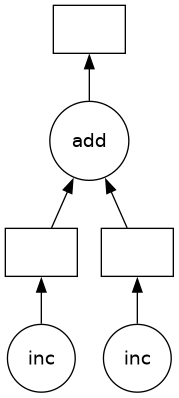

In [8]:
# 查看 `z` 的任务图
z.visualize()


注意图里出现了前面那些函数的名字，以及 `inc` 的输出如何流入 `add` 的输入。


### 几个值得思考的问题：

-  为什么从 3 秒变成了 2 秒？为什么没法并行到 1 秒？
-  如果 `inc` 和 `add` 里没有 `sleep(1)`，会发生什么？Dask 还能加速这段代码吗？
-  如果我们有多个输出，或者也想拿到 `x` 或 `y`，该怎么办？


## 练习：并行化 for 循环

`for` 循环是我们最常想并行化的结构之一。请对下面的 `inc` 和 `sum` 使用 `dask.delayed`，把这段计算并行化：


In [9]:
data = [1, 2, 3, 4, 5, 6, 7, 8]

In [10]:
%%time
# 顺序执行的代码


def inc(x):
    sleep(1)
    return x + 1


results = []
for x in data:
    y = inc(x)
    results.append(y)

total = sum(results)


CPU times: user 159 ms, sys: 27.7 ms, total: 187 ms
Wall time: 8.01 s


In [11]:
total

44

In [12]:
%%time
# 在此编写你的并行代码...


CPU times: user 1e+03 ns, sys: 1e+03 ns, total: 2 μs
Wall time: 3.81 μs


In [13]:
@dask.delayed
def inc(x):
    sleep(1)
    return x + 1


results = []
for x in data:
    y = inc(x)
    results.append(y)

total = sum(results)
print("计算前:", total)  # 看看 total 现在是什么类型
result = total.compute()
print("计算后:", result)  # 真正计算之后


计算前: Delayed('add-997f42509483521c8fccec0dc35439d7')


计算后: 44


对比一下：直接使用 `sum`、以及把 `sum` 也用 `delayed` 包起来，两种做法的任务图有什么不同？你能解释后一种吗？下面这个表达式的结果或许会有启发：
```python
inc(1) + inc(2)
```


## 练习：带控制流的 for 循环并行化

我们常常只想延迟 *一部分* 函数，让另外一些立刻执行。当那些函数很快、并且能帮我们决定接下来该调用哪些更慢的函数时，这一点特别有用。用 `dask.delayed` 时，最需要动脑的通常就是：延迟还是不延迟。

下面的例子会遍历一组输入。如果输入是偶数就调用 `inc`，如果是奇数就调用 `double`。这个 `is_even` 判断必须立刻做完（不能惰性），这样构建任务图的 Python 代码才能继续往下走。


In [14]:
def double(x):
    sleep(1)
    return 2 * x


def is_even(x):
    return not x % 2


data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [15]:
%%time
# 顺序执行的代码

results = []
for x in data:
    if is_even(x):
        y = double(x)
    else:
        y = inc(x)
    results.append(y)

total = sum(results)
print(total)


Delayed('add-c510cb5e94700cd52471fc65b90d4ac9')
CPU times: user 94.1 ms, sys: 22.1 ms, total: 116 ms
Wall time: 5.01 s


In [16]:
%%time
# 在此编写你的并行代码...
# TODO: 用 dask.delayed 把上面的顺序代码并行化
# 你需要延迟一部分函数，但不是全部


CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 4.05 μs


In [17]:
@dask.delayed
def double(x):
    sleep(1)
    return 2 * x


results = []
for x in data:
    if is_even(x):  # 偶数
        y = double(x)
    else:  # 奇数
        y = inc(x)
    results.append(y)

total = sum(results)


In [18]:
%time total.compute()

CPU times: user 83.7 ms, sys: 12.5 ms, total: 96.1 ms
Wall time: 3.04 s


90

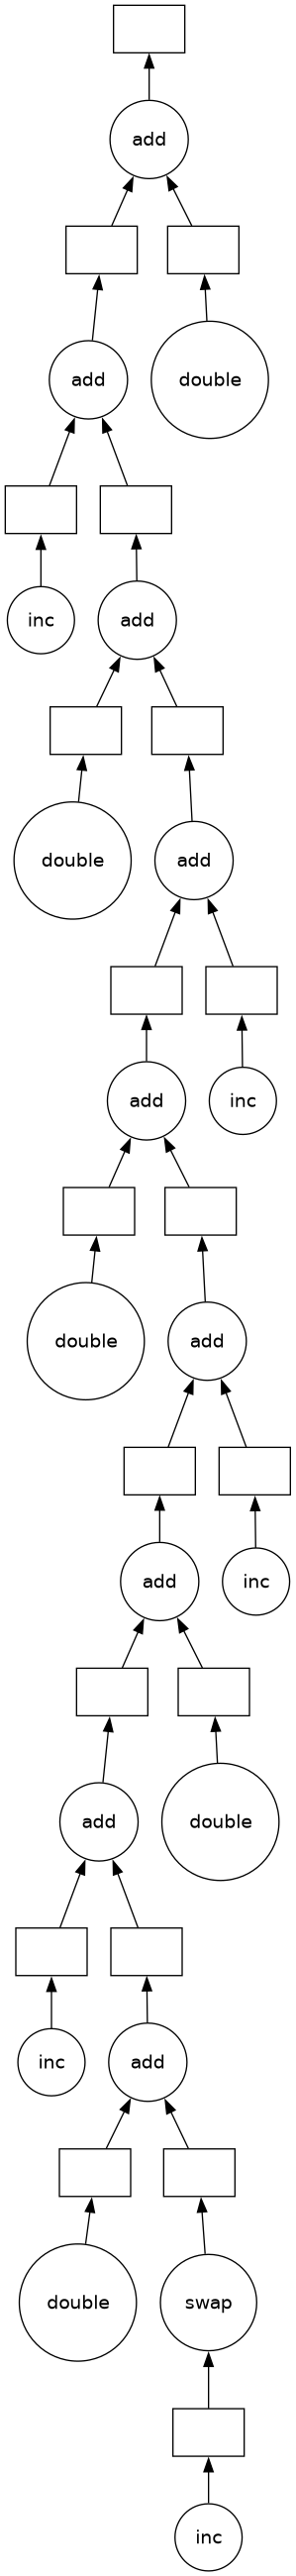

In [19]:
total.visualize()

### 几个值得思考的问题：

-  还有哪些控制流场景没法使用 delayed？
-  如果把上面例子里的 `is_even(x)` 也延迟求值，会发生什么？
-  你觉得该不该延迟 `sum`？这个函数既有计算量，又跑得很快。


## 练习：并行化 Pandas 的 groupby 归约

这个练习会读取多个 CSV，并并行做 groupby。我们先给出顺序代码，再用 `dask.delayed` 并行化。

要并行的计算是：根据一些历史航班数据，求每个机场的平均起飞延误。我们会把 `dask.delayed` 和 `pandas` 搭配使用。本教程前面的 DataFrame 章节已经用 `dask.dataframe` 做过类似的事。


## 准备数据

运行下面的代码来准备数据。

这会下载并解压 1990–2000 年从纽约出发的历史航班数据。原始数据来自[这里](http://stat-computing.org/dataexpo/2009/the-data.html)。


In [20]:
%run prep.py -d flights

### 查看数据


In [21]:
import os

sorted(os.listdir(os.path.join("data", "nycflights")))

['1990.csv',
 '1991.csv',
 '1992.csv',
 '1993.csv',
 '1994.csv',
 '1995.csv',
 '1996.csv',
 '1997.csv',
 '1998.csv',
 '1999.csv']

### 用 `pandas.read_csv` 读取一个文件，并计算平均起飞延误


In [22]:
import pandas as pd

df = pd.read_csv(os.path.join("data", "nycflights", "1990.csv"))
df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
0,1990,1,1,1,1621.0,1540,1747.0,1701,US,33,...,NaN,46.0,41.0,EWR,PIT,319.0,NaN,NaN,0,0
1,1990,1,2,2,1547.0,1540,1700.0,1701,US,33,...,NaN,-1.0,7.0,EWR,PIT,319.0,NaN,NaN,0,0
2,1990,1,3,3,1546.0,1540,1710.0,1701,US,33,...,NaN,9.0,6.0,EWR,PIT,319.0,NaN,NaN,0,0
3,1990,1,4,4,1542.0,1540,1710.0,1701,US,33,...,NaN,9.0,2.0,EWR,PIT,319.0,NaN,NaN,0,0
4,1990,1,5,5,1549.0,1540,1706.0,1701,US,33,...,NaN,5.0,9.0,EWR,PIT,319.0,NaN,NaN,0,0


In [23]:
# 数据模式（schema）是什么样的？
df.dtypes


Year                   int64
Month                  int64
DayofMonth             int64
DayOfWeek              int64
DepTime              float64
CRSDepTime             int64
ArrTime              float64
CRSArrTime             int64
UniqueCarrier         object
FlightNum              int64
TailNum              float64
ActualElapsedTime    float64
CRSElapsedTime         int64
AirTime              float64
ArrDelay             float64
DepDelay             float64
Origin                object
Dest                  object
Distance             float64
TaxiIn               float64
TaxiOut              float64
Cancelled              int64
Diverted               int64
dtype: object

In [24]:
# 数据里有哪些出发机场？
df.Origin.unique()


array(['EWR', 'LGA', 'JFK'], dtype=object)

In [25]:
# 某一年、按出发机场分组的平均起飞延误
df.groupby("Origin").DepDelay.mean()


Origin
EWR    10.854962
JFK    17.027397
LGA    10.895592
Name: DepDelay, dtype: float64

### 顺序代码：每个机场的平均起飞延误

上一格算的是某一年、按机场分组的平均起飞延误。这里用顺序 for 循环扩展到所有年份。


In [26]:
from glob import glob

filenames = sorted(glob(os.path.join("data", "nycflights", "*.csv")))

In [27]:
%%time

sums = []
counts = []
for fn in filenames:
    # 读入文件
    df = pd.read_csv(fn)

    # 按出发机场分组
    by_origin = df.groupby("Origin")

    # 按出发地汇总起飞延误
    total = by_origin.DepDelay.sum()

    # 按出发地统计航班数
    count = by_origin.DepDelay.count()

    # 保存中间结果
    sums.append(total)
    counts.append(count)

# 合并中间结果，得到每个出发地的总平均延误
total_delays = sum(sums)
n_flights = sum(counts)
mean = total_delays / n_flights


CPU times: user 30.7 ms, sys: 1.05 ms, total: 31.7 ms
Wall time: 31 ms


In [28]:
mean

Origin
EWR    12.500968
JFK          NaN
LGA    10.169227
Name: DepDelay, dtype: float64

### 把上面的代码并行化

用 `dask.delayed` 并行化上面的代码。你还需要知道几点：

1.  delayed 对象上的方法和属性访问会自动工作：如果你有一个 delayed 对象，可以对它做普通算术、切片和方法调用，它会生成正确的延迟调用。
    
2.  只有一个输出时，调用 `.compute()` 就很好用。有多个输出时，更适合用 `dask.compute` 函数，这样 Dask 可以共享中间值。
    
你的目标是用 `dask.delayed` 并行化下面这段（从上面复制而来的）代码。你也可以可视化一下计算过程，确认自己做得对不对。


In [29]:
%%time
# 在此编写代码


CPU times: user 1 μs, sys: 0 ns, total: 1 μs
Wall time: 3.81 μs


如果加载了参考答案，请在单元格顶部加上 `%%time` 来测量运行时间。


In [30]:
%%time

# 这只是一种可能的写法，用 `dask.delayed` 还有好几种做法


@dask.delayed
def read_file(filename):
    # 读入文件
    return pd.read_csv(filename)


sums = []
counts = []
for fn in filenames:
    # 延迟读取文件
    df = read_file(fn)

    # 按出发机场分组
    by_origin = df.groupby("Origin")

    # 按出发地汇总起飞延误
    total = by_origin.DepDelay.sum()

    # 按出发地统计航班数
    count = by_origin.DepDelay.count()

    # 保存中间结果
    sums.append(total)
    counts.append(count)

# 合并中间结果，得到每个出发地的总平均延误
total_delays = sum(sums)
n_flights = sum(counts)
mean, *_ = dask.compute(total_delays / n_flights)


CPU times: user 70.9 ms, sys: 5.36 ms, total: 76.3 ms
Wall time: 405 ms


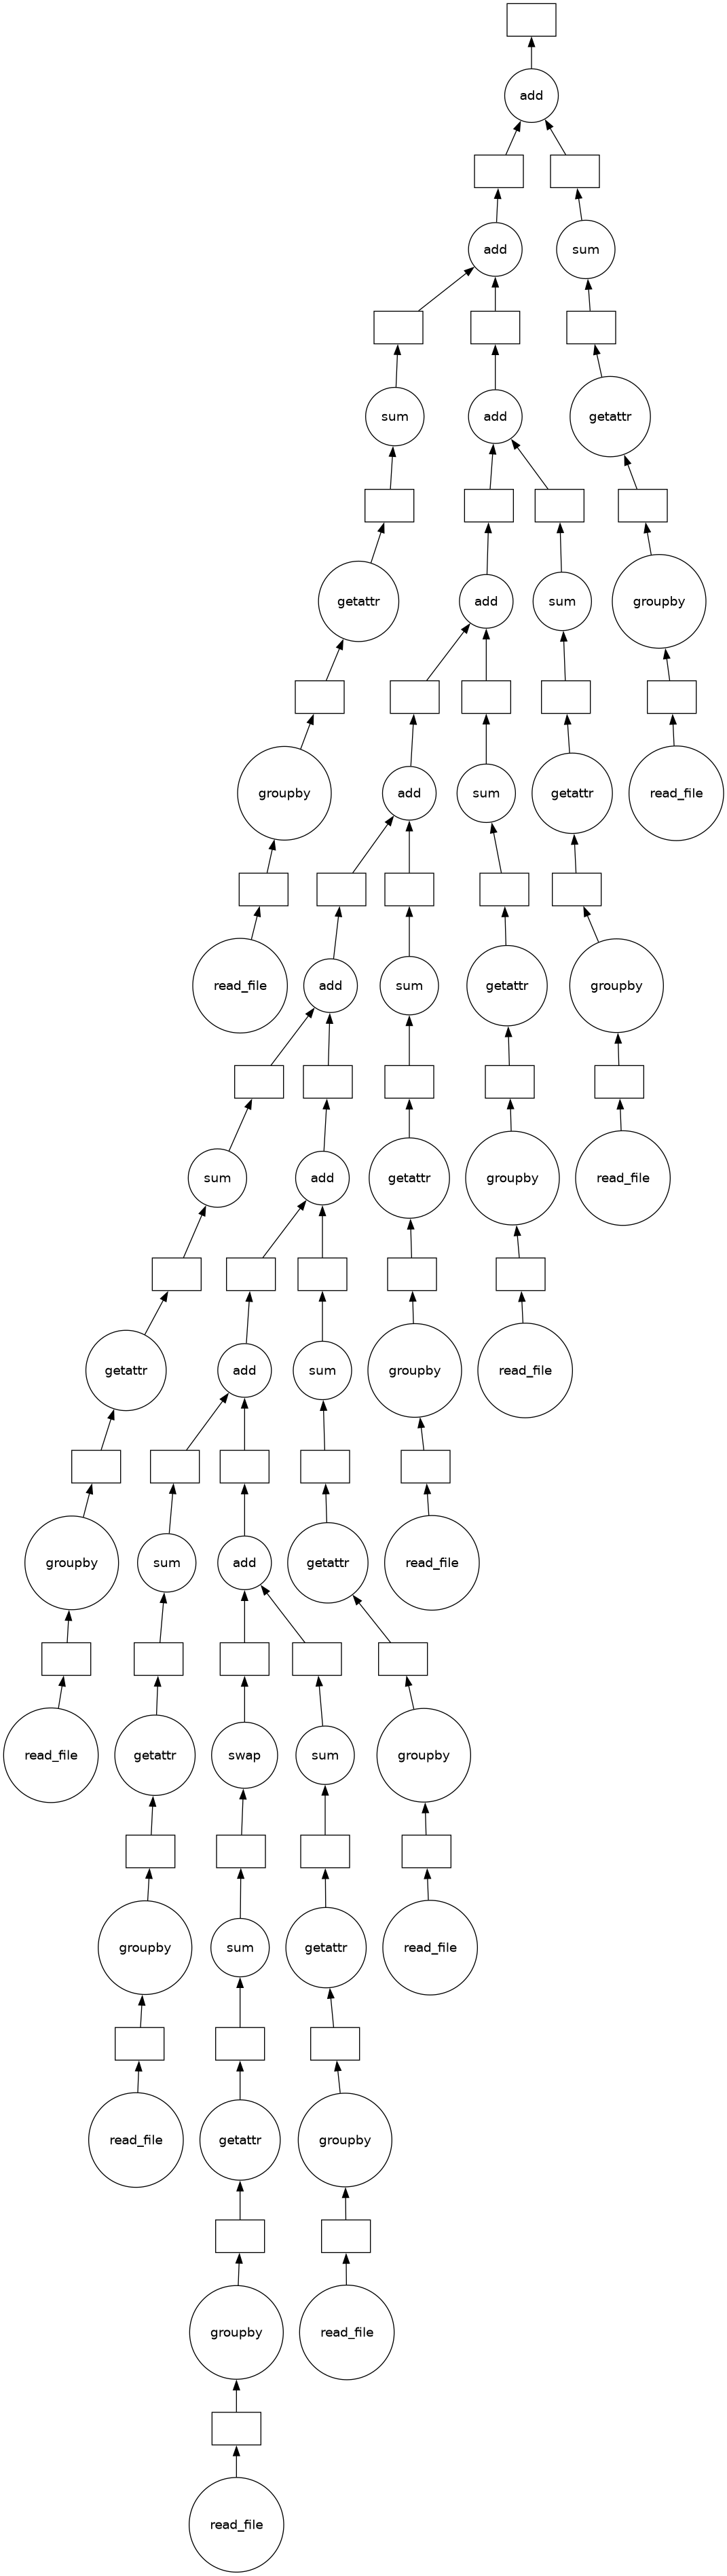

In [31]:
(sum(sums)).visualize()

In [32]:
# 确认结果仍然一致
mean


Origin
EWR    12.500968
JFK          NaN
LGA    10.169227
Name: DepDelay, dtype: float64

### 几个值得思考的问题：

- 你获得了多少加速？这符合你的预期吗？
- 试着改变调用 `compute` 的位置。对 `sums` 和 `counts` 调用会发生什么？等到 `mean` 再调用又会怎样？
- 试着延迟对 `sum` 的调用。`sum` 被延迟时任务图是什么样？不延迟又是什么样？
- 你能想到为什么有时会更想用某一种归约方式吗？

### 进一步学习

请阅读 [Delayed 文档](https://docs.dask.org/en/latest/delayed.html)。尤其是这个 [delayed 视频](https://www.youtube.com/watch?v=SHqFmynRxVU)，可以巩固这里学到的概念；另外 [delayed 最佳实践](https://docs.dask.org/en/latest/delayed-best-practices.html) 汇总了用好 `dask.delayed` 的建议。


## 关闭 Client

进入下一节练习之前，请关闭你的 client，或停止这个 kernel。


In [33]:
client.close()